<a href="https://colab.research.google.com/github/NguyenThien1906/Image-Video-Processing/blob/main/src/convolution_layer.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

This work is brought to you by Ng T Thien.

The work is based on Tensorflow library for ML use.

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
(256, 256, 3)


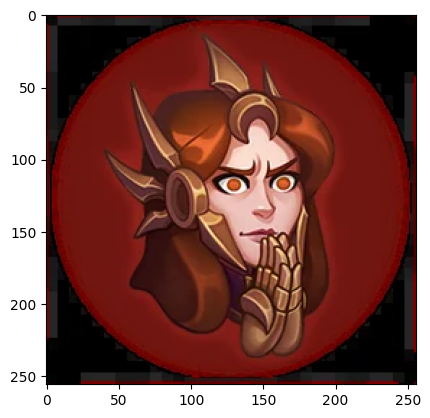

In [ ]:
# image
from google.colab import drive
drive.mount('/content/drive')
image_path = '/content/drive/MyDrive/leona_icon.jpg'
import cv2
from matplotlib import pyplot as plt
import numpy as np
image = cv2.imread(image_path)
image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
image = image.astype(np.uint8)
print(image.shape)
plt.imshow(image)

In [ ]:
# kernel3d
import numpy as np
kernel2d = np.array([[1, 1, 1, 1, 1],
                    [1, 1, 1, 1, 1],
                    [1, 1, 1, 1, 1],
                    [1, 1, 1, 1, 1],
                    [1, 1, 1, 1, 1]\
                    ], dtype=np.int16).reshape(5,5)
print(kernel2d)

[[1 1 1 1 1]
 [1 1 1 1 1]
 [1 1 1 1 1]
 [1 1 1 1 1]
 [1 1 1 1 1]]


# CPU implementation

## Basic Convolution

Convolution in image processing is simply applying a kernel, **usually squared**, on an image input to extract possible features.

Convolution at its simplest form has a 2D RGB image sized H x W x C, and a square kernel sized N x N (x C), and no padding or some sort, and stride S. So the answer we get is a feature map sized ((H - N)/S + 1) x ((W - N)/S + 1).

For example: Image 32x32x3. Kernel size 3x3.
- If stride 1, output size 30x30.
- If stride 2, output size 15x15.

In [ ]:
def trunc(val, min, max):
  if val < min:
    return min
  elif val > max:
    return max
  return val

def trunc_pixel(pix, min, max):
  for i in range(len(pix)):
    pix[i] = trunc(pix[i], min, max)
  return pix

import math

def conv1_cpu(image, kernel, kernel_sum, str, output):
  for y in range(output_shape[1]):
    for x in range(output_shape[0]):
      sum = 0
      for y_t in range(kernel.shape[1]):
        for x_t in range(kernel.shape[0]):
          for i in range(3):
            sum += image[x+x_t,y+y_t,i] * kernel[x_t,y_t]
      output[x,y] = np.uint8(trunc(sum / kernel_sum, 0, 255))

(252, 252, 1)


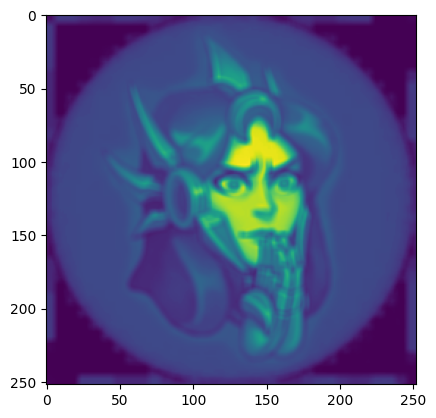

In [ ]:
stride = 1
output_shape = (math.floor((image.shape[0] - kernel2d.shape[0]) / stride) + 1,
                math.floor((image.shape[1] - kernel2d.shape[1]) / stride) + 1,
                1)
kernel_sum = np.sum(kernel2d) * 3
print(output_shape)
output = np.full(output_shape, fill_value = 0, dtype = np.uint8)
conv1_cpu(image, kernel2d, kernel_sum, stride, output)
plt.imshow(output)

## Dilated convolution

Some networks have convolutional layer stated with kernel size like 3x3/2 (in YOLOv4 for example), where 3x3 states the size of the meaningful parts, with 2 as the kernel stride. In truth, the meaningful parts are distant by 2 instead of the usual 1, making the real kernel size applied is 5x5 (3x2-1), where the non-meaningful parts are 0.

That should be noted in reducing computations, compared to an actual 5x5(/1) kernel.

In [ ]:
def conv2_cpu(image, kernel, kernel_sum, kernel_str, str, output):
  for y in range(output_shape[1]):
    for x in range(output_shape[0]):
      sum = 0
      for y_t in range(kernel.shape[1]):
        for x_t in range(kernel.shape[0]):
          for i in range(3):
            sum += image[x+x_t*kernel_str,y+y_t*kernel_str,i] * kernel[x_t,y_t]
      output[x,y] = np.uint8(trunc(sum / kernel_sum, 0, 255))

(248, 248, 1)


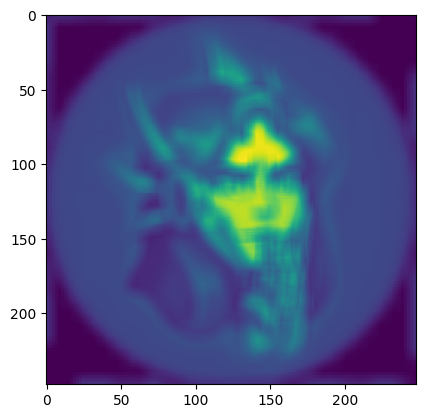

In [ ]:
stride = 1
kernel_stride = 2
output_shape = (math.floor((image.shape[0] - (kernel2d.shape[0] * kernel_stride - 1)) / stride) + 1,
                math.floor((image.shape[1] - (kernel2d.shape[1] * kernel_stride - 1)) / stride) + 1,
                1)
kernel_sum = np.sum(kernel2d) * 3
print(output_shape)
output = np.full(output_shape, fill_value = 0, dtype = np.uint8)
conv2_cpu(image, kernel2d, kernel_sum, kernel_stride, stride, output)
plt.imshow(output)

## Padding

For simplicity at first, we will only implement duplicate padding. Basically as the pixel indexes get outside the image, its value should trace back to the closest pixel.

In [ ]:
def

def conv3_cpu(image, kernel, kernel_sum, kernel_str, str, output):
  for y in range(output_shape[1]):
    for x in range(output_shape[0]):
      sum = 0
      for y_t in range(kernel.shape[1]):
        for x_t in range(kernel.shape[0]):
          for i in range(3):
            sum += image[x+x_t*kernel_str,y+y_t*kernel_str,i] * kernel[x_t,y_t]
      output[x,y] = np.uint8(trunc(sum / kernel_sum, 0, 255))